# Wstępna eksploracja przestrzeni parametrów

## Topologia meeting (sieci o strukturze społeczności)

In [109]:
import os
import glob

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="darkgrid")

# ============================================================
# LOAD RESULTS
# ============================================================

RESULTS_PATH = "./results"

files = glob.glob(os.path.join(RESULTS_PATH, "meeting*.csv"))

print("Loaded files:")
for f in files:
    print(os.path.basename(f))

dfs = []

for file in files:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_meeting = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_meeting)}")

display(df_meeting.head())

print("\nColumns:")
print(df_meeting.columns.tolist())

Loaded files:
meeting-200-5.csv
meeting-300-5.csv
meeting-100-5.csv
meeting-50-5.csv
meeting-500-5.csv
meeting-300-5_2.csv
meeting-500-5_2.csv

Total rows: 148


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
0,16,meeting,200,5,5,5,500,0.0005,1.0,0.001,0.8,208.749015,147.829984,meeting-200-5.csv
1,18,meeting,200,5,5,5,500,0.0010,1.0,0.001,0.8,208.509309,145.618709,meeting-200-5.csv
2,17,meeting,200,5,5,5,500,0.0005,2.0,0.001,0.8,202.959956,124.867465,meeting-200-5.csv
3,19,meeting,200,5,5,5,500,0.0010,2.0,0.001,0.8,203.742068,124.867465,meeting-200-5.csv
4,20,meeting,200,5,5,10,500,0.0005,1.0,0.001,0.8,227.074411,134.306445,meeting-200-5.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'z_star', 'n_steps', 'r0', 'r1', 'gamma', 'build_target_ratio', 'average', 'best', 'source_file']


In [110]:
# ============================================================
# MEAN RESULTS BY NUMBER OF ISLANDS
# ============================================================

df_mean = (
    df_meeting.groupby("number_of_islands", as_index=False)
    .agg({
        "best": "mean",
        "average": "mean",
    })
)

display(df_mean)

,number_of_islands,best,average
0,50,273.050723,312.805340
1,100,220.874301,304.710534
2,200,134.450687,215.257790
3,300,87.083745,139.576201
4,500,68.101952,112.227768


/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_1387/845645730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


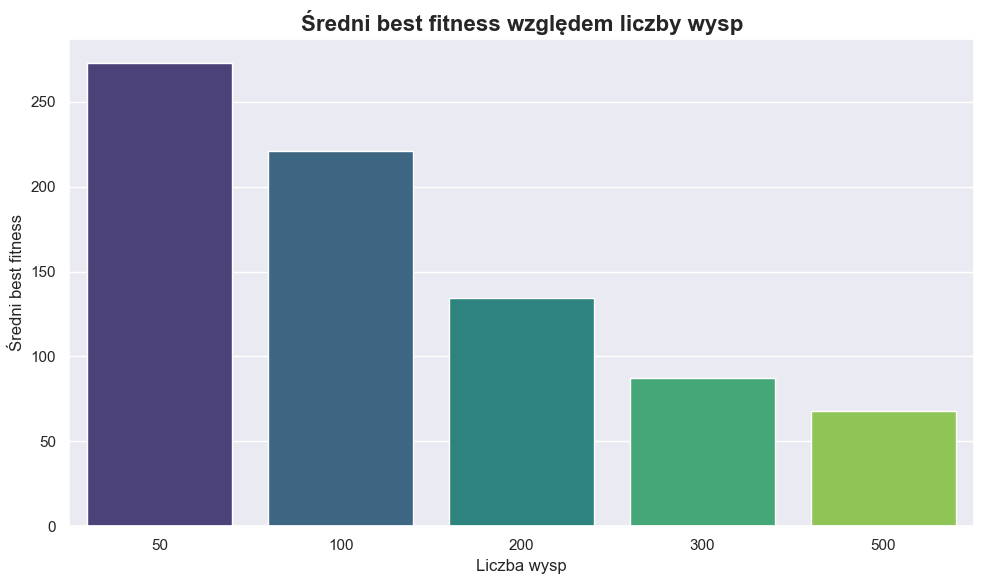

In [111]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mean,
    x="number_of_islands",
    y="best",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.tight_layout()
plt.show()

/var/folders/y3/yq4_6mjd0vxdjk2jv9k082q00000gn/T/ipykernel_1387/289990158.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


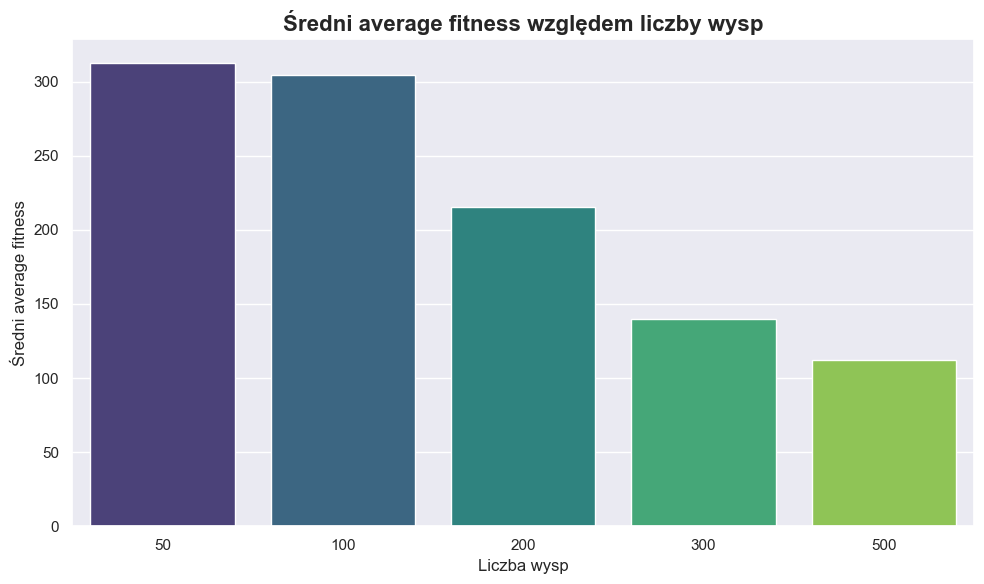

In [112]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_mean,
    x="number_of_islands",
    y="average",
    palette="viridis",
)

plt.title(
    "Średni average fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni average fitness")

plt.tight_layout()
plt.show()

In [113]:
# ============================================================
# BEST CONFIGURATION FOR EACH NUMBER OF ISLANDS
# ============================================================

idx = df_meeting.groupby("number_of_islands")["best"].idxmin()

df_best_configs = df_meeting.loc[idx].sort_values("number_of_islands")

display(df_best_configs)

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
75,4,meeting,50,5,5,10,500,0.0005,1.0,0.001,0.8,279.550641,252.607229,meeting-50-5.csv
67,14,meeting,100,5,5,10,500,0.0010,1.0,0.001,0.8,320.186768,200.337405,meeting-100-5.csv
7,23,meeting,200,5,5,10,500,0.0010,2.0,0.001,0.8,196.038053,117.310979,meeting-200-5.csv
58,50,meeting,300,5,5,10,1000,0.0010,2.0,0.005,0.8,122.932430,66.554952,meeting-300-5.csv
116,92,meeting,500,5,5,10,1000,0.0005,1.0,0.005,0.8,74.559198,40.757107,meeting-500-5.csv


In [114]:
important_cols = [
    "number_of_islands",
    "best",
    "average",
    "z_star",
    "n_steps",
    "r0",
    "r1",
    "gamma",
]

display(df_best_configs[important_cols])

,number_of_islands,best,average,z_star,n_steps,r0,r1,gamma
75,50,252.607229,279.550641,10,500,0.0005,1.0,0.001
67,100,200.337405,320.186768,10,500,0.0010,1.0,0.001
7,200,117.310979,196.038053,10,500,0.0010,2.0,0.001
58,300,66.554952,122.932430,10,1000,0.0010,2.0,0.005
116,500,40.757107,74.559198,10,1000,0.0005,1.0,0.005


In [115]:
# 10 best configurations for meeting globally
top10_meeting = (
    df_meeting
    .sort_values("best")
    .head(10)
)

display(top10_meeting[important_cols])

,number_of_islands,best,average,z_star,n_steps,r0,r1,gamma
116,500,40.757107,74.559198,10,1000,0.00050,1.0,0.0050
125,500,41.976226,85.165508,10,1000,0.00100,1.0,0.0050
145,500,45.813507,81.478631,10,500,0.00100,1.0,0.0010
129,500,46.901369,79.978807,10,1000,0.00100,3.0,0.0005
117,500,47.636605,87.300664,10,1000,0.00050,2.0,0.0005
120,500,48.846811,94.906581,10,1000,0.00050,3.0,0.0005
110,500,50.358125,89.514222,10,1000,0.00025,2.0,0.0050
131,500,51.592144,96.145882,10,1000,0.00100,3.0,0.0050
144,500,52.599184,88.496193,10,500,0.00050,1.0,0.0010
106,500,53.186112,84.827507,10,1000,0.00025,1.0,0.0010


## Analiza parametrów

In [116]:
df_zstar = (
    df_meeting.groupby("z_star", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_zstar)

z_star        best                                       average  \
                mean        min         max        std        mean   
0      5  107.949068  65.789570  268.721847  52.477542  160.719799   
1     10   90.003890  40.757107  292.914337  58.399642  140.280679   

                                      
          min         max        std  
0  109.938320  334.818162  54.146669  
1   74.559198  330.409849  69.382026

In [117]:
df_r0 = (
    df_meeting.groupby("r0", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_r0)

r0        best                                       average  \
                  mean        min         max        std        mean   
0  0.00025   78.188678  50.358125  111.957236  15.441632  127.455395   
1  0.00050  106.935377  40.757107  277.614342  61.874620  159.569697   
2  0.00100  104.381167  41.976226  292.914337  63.570420  156.245324   

                                     
         min         max        std  
0  84.827507  159.642875  23.504696  
1  74.559198  334.818162  69.675588  
2  79.884581  323.923797  69.932159

In [119]:
df_gamma = (
    df_meeting.groupby("gamma", as_index=False)
    .agg({
        "best": ["mean", "min", "max"],
        "average": ["mean", "min", "max"],
    })
)

display(df_gamma)

gamma        best                            average             \
                 mean        min         max        mean        min   
0  0.0005   78.915115  46.901369  100.901664  127.718519  79.978807   
1  0.0010  119.200344  45.813507  292.914337  173.557576  81.478631   
2  0.0050   76.343016  40.757107  103.893597  124.605359  74.559198   

               
          max  
0  158.532766  
1  334.818162  
2  158.256393

In [120]:
df_n_steps = (
    df_meeting.groupby("n_steps", as_index=False)
    .agg({
        "best": ["mean", "min", "max"],
        "average": ["mean", "min", "max"],
    })
)

display(df_n_steps)

n_steps        best                            average             \
                 mean        min         max        mean        min   
0     500  156.172855  45.813507  292.914337  217.397134  81.478631   
1    1000   77.792636  40.757107  111.957236  125.723611  74.559198   

               
          max  
0  334.818162  
1  159.642875

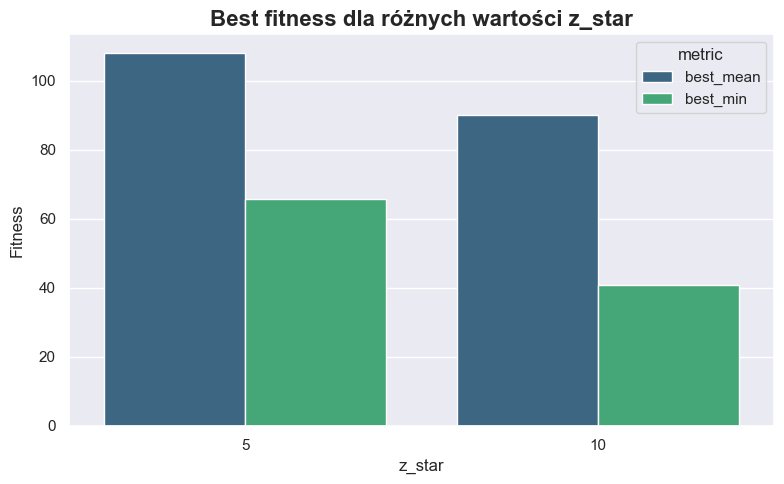

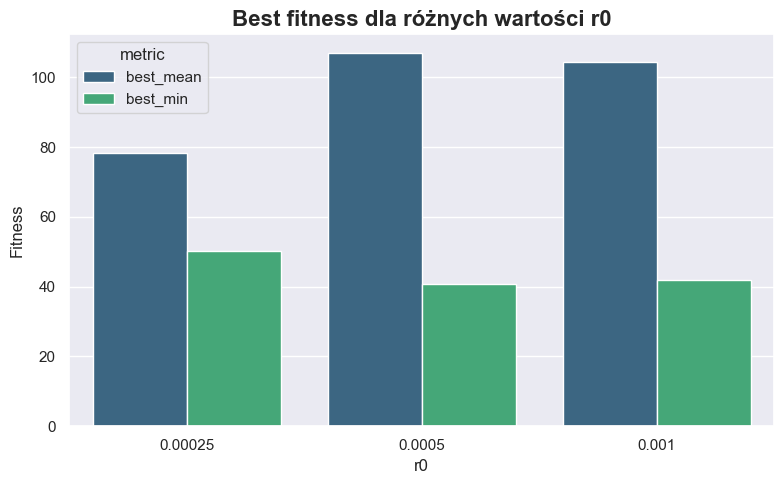

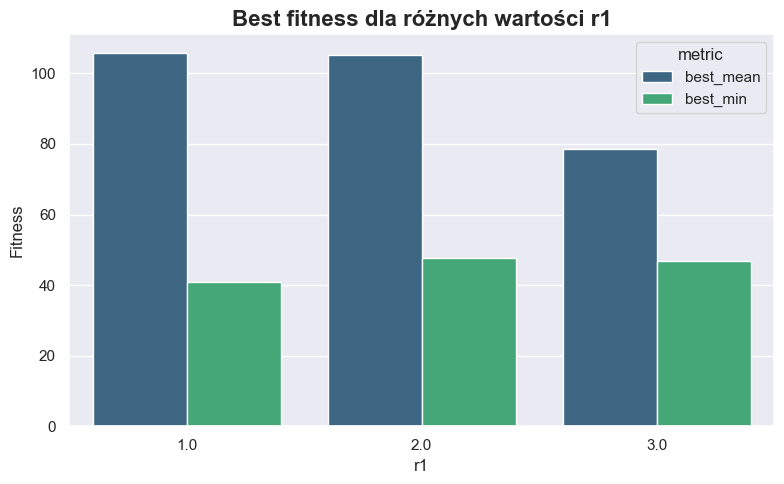

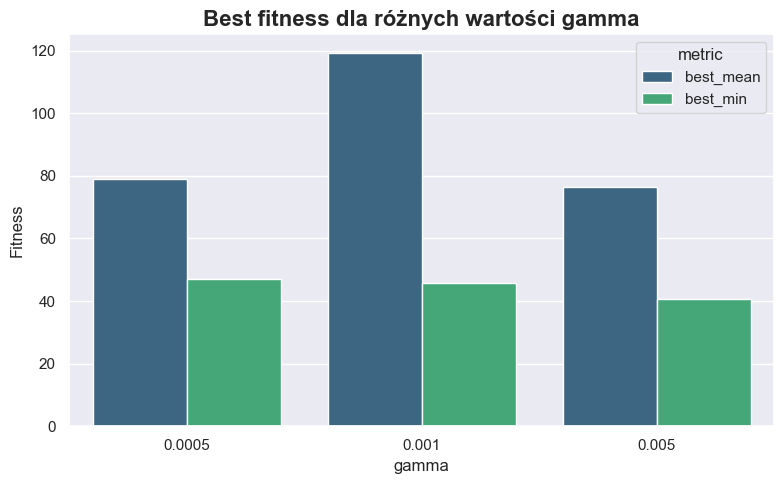

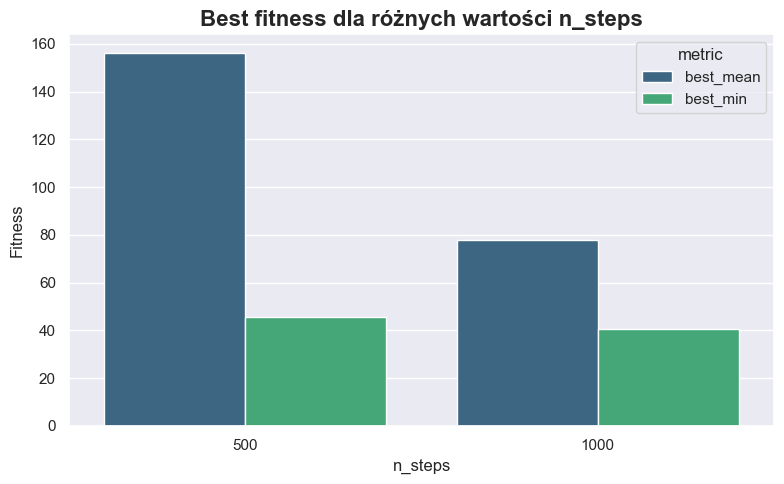

In [118]:
for param in ['z_star', 'r0', 'r1', 'gamma', 'n_steps']:

    df = (
        df_meeting.groupby(param, as_index=False)
        .agg({
            "best": ["mean", "min"],
        })
    )

    # spłaszczenie nazw kolumn
    df.columns = [
        "_".join(col).strip("_")
        for col in df.columns.values
    ]

    plot_df = df.melt(
        id_vars=param,
        value_vars=["best_mean", "best_min"],
        var_name="metric",
        value_name="value"
    )

    plt.figure(figsize=(8, 5))

    sns.barplot(
        data=plot_df,
        x=param,
        y="value",
        hue="metric",
        palette="viridis",
    )

    plt.title(
        f"Best fitness dla różnych wartości {param}",
        fontsize=16,
        fontweight="bold",
    )

    plt.xlabel(param)
    plt.ylabel("Fitness")

    plt.tight_layout()
    plt.show()


## Analiza najlepszych parametrów

In [121]:
idx = df_meeting.groupby("r0")["best"].idxmin()

display(
    df_meeting.loc[idx][
        ["r0", "best", "number_of_islands", "z_star", "r1", "gamma"]
    ].sort_values("best")
)

,r0,best,number_of_islands,z_star,r1,gamma
116,0.00050,40.757107,500,10,1.0,0.005
125,0.00100,41.976226,500,10,1.0,0.005
110,0.00025,50.358125,500,10,2.0,0.005


In [122]:
idx = df_meeting.groupby("r1")["best"].idxmin()

display(
    df_meeting.loc[idx][
        ["r1", "best", "number_of_islands", "z_star", "r0", "gamma"]
    ].sort_values("best")
)

,r1,best,number_of_islands,z_star,r0,gamma
116,1.0,40.757107,500,10,0.0005,0.0050
129,3.0,46.901369,500,10,0.0010,0.0005
117,2.0,47.636605,500,10,0.0005,0.0005


In [123]:
idx = df_meeting.groupby("gamma")["best"].idxmin()

display(
    df_meeting.loc[idx][
        ["gamma", "best", "number_of_islands", "z_star", "r0", "r1"]
    ].sort_values("best")
)

,gamma,best,number_of_islands,z_star,r0,r1
116,0.0050,40.757107,500,10,0.0005,1.0
145,0.0010,45.813507,500,10,0.0010,1.0
129,0.0005,46.901369,500,10,0.0010,3.0


In [128]:
top10 = df_meeting.sort_values("best").head(10)

top10[["best", "average", "number_of_islands", "z_star", "n_steps", "r0", "r1", "gamma"]]

,best,average,number_of_islands,z_star,n_steps,r0,r1,gamma
116,40.757107,74.559198,500,10,1000,0.00050,1.0,0.0050
125,41.976226,85.165508,500,10,1000,0.00100,1.0,0.0050
145,45.813507,81.478631,500,10,500,0.00100,1.0,0.0010
129,46.901369,79.978807,500,10,1000,0.00100,3.0,0.0005
117,47.636605,87.300664,500,10,1000,0.00050,2.0,0.0005
120,48.846811,94.906581,500,10,1000,0.00050,3.0,0.0005
110,50.358125,89.514222,500,10,1000,0.00025,2.0,0.0050
131,51.592144,96.145882,500,10,1000,0.00100,3.0,0.0050
144,52.599184,88.496193,500,10,500,0.00050,1.0,0.0010
106,53.186112,84.827507,500,10,1000,0.00025,1.0,0.0010


## Zapis parametrów z najlepszych konfiguracji (10 dla 500 wysp, 3 dla pozostałych)

In [129]:
top3_per_islands = (
    df_meeting
    .sort_values("best")
    .groupby("number_of_islands")
    .head(3)
)

In [130]:
top3_per_islands

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,build_target_ratio,average,best,source_file
116,92,meeting,500,5,5,10,1000,0.00050,1.0,0.005,0.8,74.559198,40.757107,meeting-500-5.csv
125,101,meeting,500,5,5,10,1000,0.00100,1.0,0.005,0.8,85.165508,41.976226,meeting-500-5.csv
145,14,meeting,500,5,5,10,500,0.00100,1.0,0.001,0.8,81.478631,45.813507,meeting-500-5_2.csv
58,50,meeting,300,5,5,10,1000,0.00100,2.0,0.005,0.8,122.932430,66.554952,meeting-300-5.csv
137,6,meeting,300,5,5,10,500,0.00100,1.0,0.001,0.8,125.371358,68.884488,meeting-300-5_2.csv
40,32,meeting,300,5,5,10,1000,0.00025,2.0,0.005,0.8,107.918596,70.580372,meeting-300-5.csv
7,23,meeting,200,5,5,10,500,0.00100,2.0,0.001,0.8,196.038053,117.310979,meeting-200-5.csv
3,19,meeting,200,5,5,5,500,0.00100,2.0,0.001,0.8,203.742068,124.867465,meeting-200-5.csv
2,17,meeting,200,5,5,5,500,0.00050,2.0,0.001,0.8,202.959956,124.867465,meeting-200-5.csv
67,14,meeting,100,5,5,10,500,0.00100,1.0,0.001,0.8,320.186768,200.337405,meeting-100-5.csv


In [50]:
# top10 = df_meeting.sort_values("best").head(10)

param_cols = top3_per_islands.columns[2:10] # ignoruje pierwsze 2 i ostatnie 4 kolumny
top3 = top3_per_islands[top3_per_islands['number_of_islands']!=500]

out = top3[param_cols].copy()

# Dla częsci wcześniejszych eksperymentów nie było zapisu tych parametrów, więc dodałem je ręcznie. W nowszej wersji zapisują się automatycznie
out["build_target_ratio"] = 0.8
out["seed"] = 123

# powtarzamy każdą konfigurację parametrów 5-krotnie
out_repeated = out.loc[out.index.repeat(5)].reset_index(drop=True)

out_repeated.to_csv(
    "top3_repeated.txt",
    sep=" ",
    header=False,
    index=False
)

In [49]:
out_repeated

,number_of_islands,number_of_migrants,migration_interval,z_star,n_steps,r0,r1,gamma,p,seed
0,300,5,5,10,1000,0.00100,2.0,0.005,0.8,12
1,300,5,5,10,1000,0.00100,2.0,0.005,0.8,12
2,300,5,5,10,1000,0.00100,2.0,0.005,0.8,12
3,300,5,5,10,1000,0.00100,2.0,0.005,0.8,12
4,300,5,5,10,1000,0.00100,2.0,0.005,0.8,12
5,300,5,5,10,500,0.00100,1.0,0.001,0.8,12
6,300,5,5,10,500,0.00100,1.0,0.001,0.8,12
7,300,5,5,10,500,0.00100,1.0,0.001,0.8,12
8,300,5,5,10,500,0.00100,1.0,0.001,0.8,12
9,300,5,5,10,500,0.00100,1.0,0.001,0.8,12


## Topologia scale-free (bezskalowa)

In [131]:
files2 = glob.glob(os.path.join(RESULTS_PATH, "scale_free*.csv"))

print("Loaded files:")
for f in files2:
    print(os.path.basename(f))

dfs = []

for file in files2:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_scale_free = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_scale_free)}")

display(df_scale_free.head())

print("\nColumns:")
print(df_scale_free.columns.tolist())

Loaded files:
scale_free_n500_array_20089410.csv
scale_free-500-5.csv
scale_free_n100_array_20089410.csv
scale_free_n200_array_20089410.csv
scale_free-300-5.csv
scale_free_n50_array_20089410.csv
scale_free_n300_array_20089410.csv

Total rows: 96


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,build_target_ratio
0,65,scale_free,500,5,5,3,2,123.0,802.280096,140.086448,scale_free_n500_array_20089410.csv,NaN
1,66,scale_free,500,5,5,3,3,123.0,357.705721,94.833971,scale_free_n500_array_20089410.csv,NaN
2,69,scale_free,500,5,5,5,3,123.0,374.688380,71.344838,scale_free_n500_array_20089410.csv,NaN
3,70,scale_free,500,5,5,5,4,123.0,323.786031,70.063920,scale_free_n500_array_20089410.csv,NaN
4,64,scale_free,500,5,5,3,1,123.0,803.087625,146.289448,scale_free_n500_array_20089410.csv,NaN



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'm0', 'm', 'seed', 'average', 'best', 'source_file', 'build_target_ratio']


In [132]:
# ============================================================
# MEAN RESULTS BY NUMBER OF ISLANDS
# ============================================================

df_mean = (
    df_scale_free.groupby("number_of_islands", as_index=False)
    .agg({
        "best": "mean",
        "average": "mean",
    })
)

display(df_mean)

,number_of_islands,best,average
0,50,279.508445,336.627721
1,100,200.370932,321.654215
2,200,132.861846,359.284206
3,300,105.792290,383.211688
4,500,91.166010,396.063883


In [133]:
# ============================================================
# BEST CONFIGURATION FOR EACH NUMBER OF ISLANDS
# ============================================================

idx = df_scale_free.groupby("number_of_islands")["best"].idxmin()

df_best_configs = df_scale_free.loc[idx].sort_values("number_of_islands")

display(df_best_configs)

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,build_target_ratio
77,15,scale_free,50,5,5,8,8,123.0,278.557241,240.791447,scale_free_n50_array_20089410.csv,NaN
32,25,scale_free,100,5,5,8,2,123.0,372.931330,182.877853,scale_free_n100_array_20089410.csv,NaN
50,46,scale_free,200,5,5,8,7,123.0,235.111680,121.091890,scale_free_n200_array_20089410.csv,NaN
91,62,scale_free,300,5,5,8,7,123.0,157.182988,60.824509,scale_free_n300_array_20089410.csv,NaN
13,78,scale_free,500,5,5,8,7,123.0,145.840448,39.527732,scale_free_n500_array_20089410.csv,NaN


In [134]:
important_cols = [
    "number_of_islands",
    "best",
    "average",
    "m0",
    "m",
]

display(df_best_configs[important_cols])

,number_of_islands,best,average,m0,m
77,50,240.791447,278.557241,8,8
32,100,182.877853,372.931330,8,2
50,200,121.091890,235.111680,8,7
91,300,60.824509,157.182988,8,7
13,500,39.527732,145.840448,8,7


In [135]:
df_m0 = (
    df_scale_free.groupby("m0", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

display(df_m0)

m0        best                                       average              \
            mean        min         max        std        mean         min   
0  3  161.568142  92.122609  291.110737  61.637682  551.296085  263.566937   
1  5  147.991269  56.588856  303.795157  76.387039  337.843082  153.541540   
2  8  148.955834  39.527732  308.241270  81.617262  289.548659  130.334723   

                            
           max         std  
0   899.293694  213.918447  
1  1149.722996  193.677667  
2   472.521685   88.433137

In [137]:
df_m0 = (
    df_scale_free.groupby("m0", as_index=False)
    .agg({
        "best": ["mean", "min", "max", "std"],
        "average": ["mean", "min", "max", "std"],
    })
)

# spłaszczenie nazw kolumn
df_m0.columns = [
    "_".join(col).strip("_")
    for col in df_m0.columns.values
]

df_m0

,m0,best_mean,best_min,best_max,best_std,average_mean,average_min,average_max,average_std
0,3,161.568142,92.122609,291.110737,61.637682,551.296085,263.566937,899.293694,213.918447
1,5,147.991269,56.588856,303.795157,76.387039,337.843082,153.541540,1149.722996,193.677667
2,8,148.955834,39.527732,308.241270,81.617262,289.548659,130.334723,472.521685,88.433137


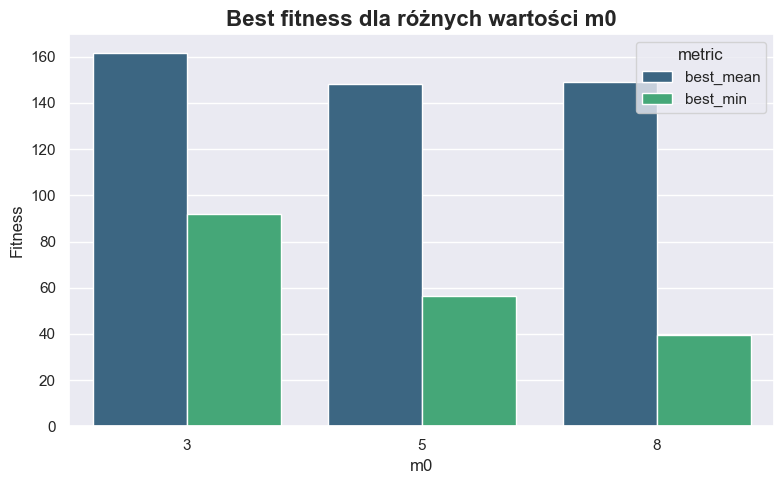

In [138]:
plot_df = df_m0.melt(
    id_vars="m0",
    value_vars=["best_mean", "best_min"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="m0",
    y="value",
    hue="metric",
    palette="viridis",
)

plt.title(
    "Best fitness dla różnych wartości m0",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("m0")
plt.ylabel("Fitness")

plt.tight_layout()
plt.show()

In [140]:
df_m = (
    df_scale_free.groupby("m", as_index=False)
    .agg({
        "best": ["mean", "min"],
        "average": ["mean", "min"],
    })
)

display(df_m)

m        best                average            
            mean        min        mean         min
0  1  170.452282  74.491411  522.157882  263.566937
1  2  158.765400  74.491411  438.088781  250.067615
2  3  152.931652  71.344838  379.720261  199.261100
3  4  141.408530  61.955258  273.061222  174.977288
4  5  136.079869  45.094046  235.489712  130.350168
5  6  137.119495  45.094046  224.248512  130.334723
6  7  132.627085  39.527732  225.112301  145.840448
7  8  138.285548  49.225603  234.977035  157.182988

In [141]:
df_m = (
    df_scale_free.groupby("m", as_index=False)
    .agg({
        "best": ["mean", "min"],
        "average": ["mean", "min"],
    })
)

# spłaszczenie nazw kolumn
df_m.columns = [
    "_".join(col).strip("_")
    for col in df_m.columns.values
]

df_m

,m,best_mean,best_min,average_mean,average_min
0,1,170.452282,74.491411,522.157882,263.566937
1,2,158.765400,74.491411,438.088781,250.067615
2,3,152.931652,71.344838,379.720261,199.261100
3,4,141.408530,61.955258,273.061222,174.977288
4,5,136.079869,45.094046,235.489712,130.350168
5,6,137.119495,45.094046,224.248512,130.334723
6,7,132.627085,39.527732,225.112301,145.840448
7,8,138.285548,49.225603,234.977035,157.182988


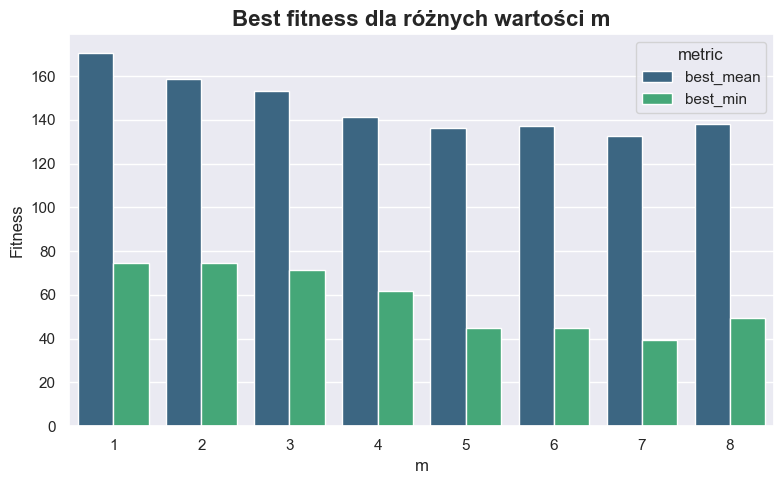

In [142]:
plot_df = df_m.melt(
    id_vars="m",
    value_vars=["best_mean", "best_min"],
    var_name="metric",
    value_name="value"
)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=plot_df,
    x="m",
    y="value",
    hue="metric",
    palette="viridis",
)

plt.title(
    "Best fitness dla różnych wartości m",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("m")
plt.ylabel("Fitness")

plt.tight_layout()
plt.show()

In [143]:
idx = df_scale_free.groupby("m0")["best"].idxmin()

display(
    df_scale_free.loc[idx][
        ["m0", "best", "number_of_islands", "m"]
    ].sort_values("best")
)

,m0,best,number_of_islands,m
13,8,39.527732,500,7
23,5,56.588856,500,5
17,3,92.122609,500,3


In [144]:
idx = df_scale_free.groupby("m")["best"].idxmin()

display(
    df_scale_free.loc[idx][
        ["m", "best", "number_of_islands", "m0"]
    ].sort_values("best")
)

,m,best,number_of_islands,m0
13,7,39.527732,500,8
14,5,45.094046,500,8
12,6,45.094046,500,8
15,8,49.225603,500,8
10,4,61.955258,500,8
2,3,71.344838,500,5
7,1,74.491411,500,5
5,2,74.491411,500,5


In [146]:
top10_per_islands = (
    df_scale_free
    .sort_values("best")
    .groupby("number_of_islands")
    .head(10)
)

top10_per_islands

,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,m0,m,seed,average,best,source_file,build_target_ratio
13,78,scale_free,500,5,5,8,7,123.0,145.840448,39.527732,scale_free_n500_array_20089410.csv,NaN
14,76,scale_free,500,5,5,8,5,123.0,130.350168,45.094046,scale_free_n500_array_20089410.csv,NaN
12,77,scale_free,500,5,5,8,6,123.0,130.334723,45.094046,scale_free_n500_array_20089410.csv,NaN
15,79,scale_free,500,5,5,8,8,123.0,158.270774,49.225603,scale_free_n500_array_20089410.csv,NaN
23,15,scale_free,500,5,5,5,5,NaN,210.790042,56.588856,scale_free-500-5.csv,0.8
6,71,scale_free,500,5,5,5,5,123.0,153.541540,58.163588,scale_free_n500_array_20089410.csv,NaN
91,62,scale_free,300,5,5,8,7,123.0,157.182988,60.824509,scale_free_n300_array_20089410.csv,NaN
92,63,scale_free,300,5,5,8,8,123.0,157.182988,60.824509,scale_free_n300_array_20089410.csv,NaN
93,60,scale_free,300,5,5,8,5,123.0,158.045072,60.851494,scale_free_n300_array_20089410.csv,NaN
10,75,scale_free,500,5,5,8,4,123.0,306.268337,61.955258,scale_free_n500_array_20089410.csv,NaN


In [147]:
param_cols = top10_per_islands.columns[2:7] # ignoruje pierwsze 2 i ostatnie 5 kolumn
top10 = top10_per_islands[top10_per_islands['number_of_islands']==500]

out = top10[param_cols].copy()
out["seed"] = 123

out_scale_free = out.loc[out.index.repeat(5)].reset_index(drop=True)

out_scale_free.to_csv(
    "top3_scale_.txt",
    sep=" ",
    header=False,
    index=False
)

## Wczytanie wyników dla topologii complete

In [100]:
files3 = glob.glob(os.path.join(RESULTS_PATH, "complete*.csv"))

print("Loaded files:")
for f in files3:
    print(os.path.basename(f))

dfs = []

for file in files3:
    df_tmp = pd.read_csv(file)

    # source filename
    df_tmp["source_file"] = os.path.basename(file)

    dfs.append(df_tmp)

df_complete = pd.concat(dfs, ignore_index=True)

print(f"\nTotal rows: {len(df_complete)}")

display(df_complete.head())

print("\nColumns:")
print(df_complete.columns.tolist())

Loaded files:
complete_n500_array_20074995.csv
complete_n300_array_20074989.csv
complete_n100_array_20089275.csv
complete_n50_array_20074989.csv
complete_n500_array_20089275.csv
complete_n200_array_20074989.csv
complete_n50_array_20089275.csv
complete_n100_array_20074989.csv
complete_n300_array_20089275.csv
complete_n200_array_20089275.csv

Total rows: 55


,array_task_id,topology,number_of_islands,number_of_migrants,migration_interval,build_target_ratio,average,best,source_file
0,local,complete,500,5,5,0.8,99.204916,46.661024,complete_n500_array_20074995.csv
1,3,complete,300,5,5,0.8,110.202610,59.757942,complete_n300_array_20074989.csv
2,10,complete,100,5,5,NaN,256.636619,194.201956,complete_n100_array_20089275.csv
3,11,complete,100,5,5,NaN,244.911136,188.233921,complete_n100_array_20089275.csv
4,12,complete,100,5,5,NaN,238.446188,183.901041,complete_n100_array_20089275.csv



Columns:
['array_task_id', 'topology', 'number_of_islands', 'number_of_migrants', 'migration_interval', 'build_target_ratio', 'average', 'best', 'source_file']


# Porównanie różnych topologii (meeting, scale-free and complete)

In [148]:
df_meeting["topology"] = "meeting"
df_scale_free["topology"] = "scale_free"
df_complete["topology"] = "complete"

df_compare = pd.concat(
    [df_meeting, df_scale_free, df_complete],
    ignore_index=True
)

In [151]:
df_best_global = (
    df_compare.groupby("topology", as_index=False)
    .agg({
        "best": "min"
    })
)

display(df_best_global)

,topology,best
0,complete,36.862251
1,meeting,40.757107
2,scale_free,39.527732


In [154]:
df_islands_compare = (
    df_compare.groupby(
        ["topology", "number_of_islands"],
        as_index=False
    )
    .agg(
        best_mean=("best", "mean"),
        best_std=("best", "std"),
        best_min=("best", "min"),
        best_max=("best", "max"),
        best_median=("best", "median")
    )
)

display(df_islands_compare)

,topology,number_of_islands,best_mean,best_std,best_min,best_max,best_median
0,complete,50,241.699778,10.814668,219.601881,253.394104,244.700878
1,complete,100,185.043258,7.534414,178.323377,202.991137,183.901041
2,complete,200,113.818040,7.287132,104.953005,130.237059,111.647743
3,complete,300,69.781145,8.156221,59.757942,85.147444,68.333403
4,complete,500,42.289465,4.358031,36.862251,50.150453,39.787748
5,meeting,50,273.050723,12.455744,252.607229,292.914337,268.721847
6,meeting,100,220.874301,15.219260,200.337405,246.575509,223.002658
7,meeting,200,134.450687,12.613903,117.310979,151.841961,131.634465
8,meeting,300,87.083745,9.838783,66.554952,111.957236,89.558338
9,meeting,500,68.101952,14.579628,40.757107,94.388311,64.933504


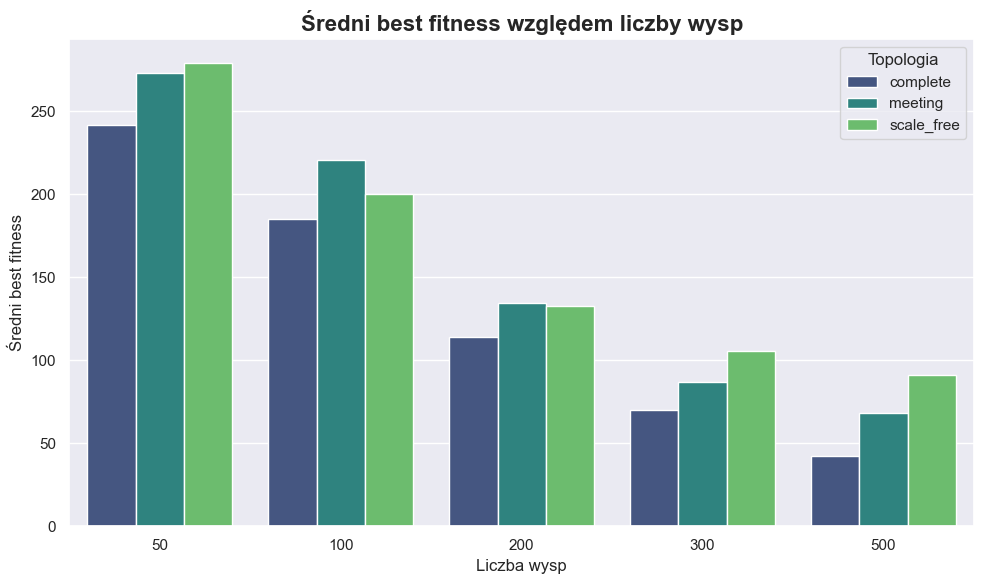

In [155]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="best_mean",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Średni best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

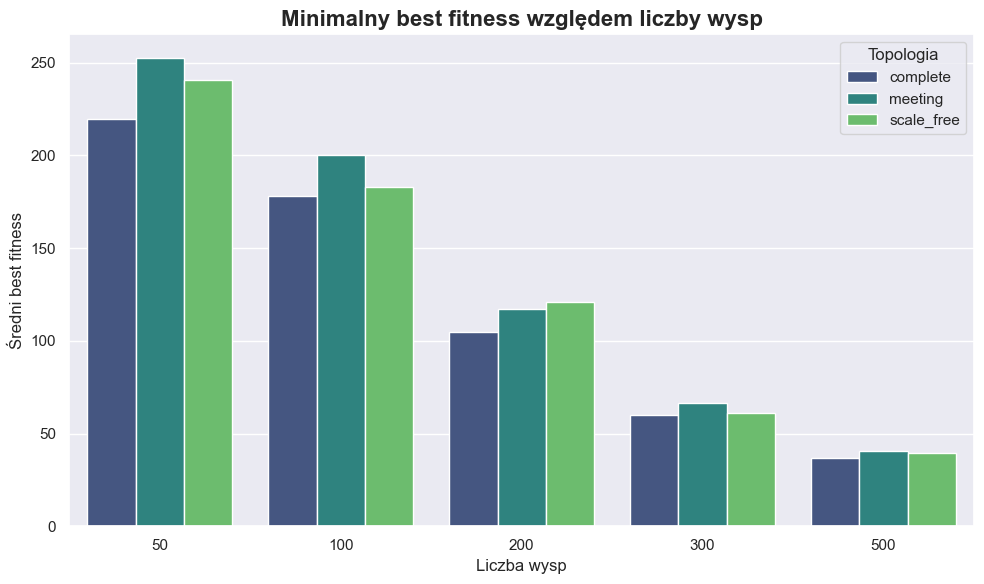

In [156]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_islands_compare,
    x="number_of_islands",
    y="best_min",
    hue="topology",
    palette="viridis",
)

plt.title(
    "Minimalny best fitness względem liczby wysp",
    fontsize=16,
    fontweight="bold",
)

plt.xlabel("Liczba wysp")
plt.ylabel("Średni best fitness")

plt.legend(title="Topologia")

plt.tight_layout()
plt.show()

In [157]:
top10 = (
    df_compare
    .sort_values("best")
    .head(10)
)

top10[["topology", "best", "average", "number_of_islands"]]

,topology,best,average,number_of_islands
262,complete,36.862251,75.793949,500
257,complete,38.606819,71.420987,500
260,complete,38.904383,67.664295,500
259,complete,38.904383,67.840728,500
161,scale_free,39.527732,145.840448,500
266,complete,39.720048,78.334388,500
265,complete,39.787748,66.297343,500
116,meeting,40.757107,74.559198,500
125,meeting,41.976226,85.165508,500
258,complete,44.215650,75.374317,500
